In [16]:
import pandas as pd
import numpy as np
# import pygwalker as pyg
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
# from dython.nominal import associations


In [2]:
df = pd.read_csv('../artifacts/raw.csv',parse_dates=['Date'])

C:\Users\Dhvanish\AppData\Local\Temp\ipykernel_20860\2408297586.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../artifacts/raw.csv',parse_dates=['Date'])


In [3]:
df.shape

(1017209, 18)

In [4]:
df['CompetitionDistance'].fillna(0,inplace=True)

df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df['CompetitionOpen_missing'] = df['CompetitionOpenSinceYear'].isna().astype(int)
df['CompetitionOpenSinceMonth'].fillna(1,inplace=True)
df['CompetitionOpenSinceYear'].fillna(df['Year'].min(),inplace=True)
df['CompetitionOpen'] = 12 * (df['Year'] - df['CompetitionOpenSinceYear']) + (df['Month'] - 
                                                                              df['CompetitionOpenSinceMonth'])
df['CompetitionOpen'] = df['CompetitionOpen'].apply(lambda x: max(x, 0))

df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['Promo2OpenSinceMonths'] = 12 * (df['Year'] - df['Promo2SinceYear']) + (df['WeekOfYear'] - 
                                                                           df['Promo2SinceWeek']) / 4.0
df['Promo2OpenSinceMonths'] = df['Promo2OpenSinceMonths'].apply(lambda x: max(x, 0) if pd.notnull(x) else 0)
df.loc[df['Promo2'] == 0, 'Promo2OpenSinceMonths'] = 0
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
df['MonthStr'] = df['Month'].map(month_map)
promo_months = df['PromoInterval'].fillna('').str.split(',')
df['IsPromoMonth'] = [
    1 if m in months else 0 
    for m, months in zip(df['MonthStr'], promo_months)
]

In [5]:
df.drop(['Store','CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear','Promo2SinceWeek','Promo2SinceYear','PromoInterval','MonthStr'], axis=1, inplace=True)

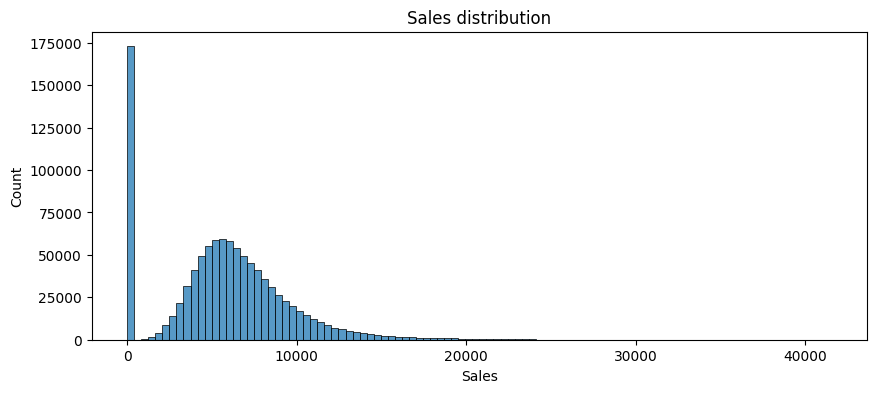

Skew: 0.6414596158103795


In [9]:
plt.figure(figsize=(10,4))
sns.histplot(df['Sales'],bins=100)
plt.title("Sales distribution")
plt.show()

df['Sales'].describe()
print(f'Skew: {df['Sales'].skew()}')

In [10]:
df.groupby('Open')['Sales'].describe()

,count,mean,std,min,25%,50%,75%,max
Open,,,,,,,,
0,172817.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0
1,844392.0,6955.514291,3104.21468,0.0,4859.0,6369.0,8360.0,41551.0


In [11]:
df_open = df[df['Open'] == 1].copy()

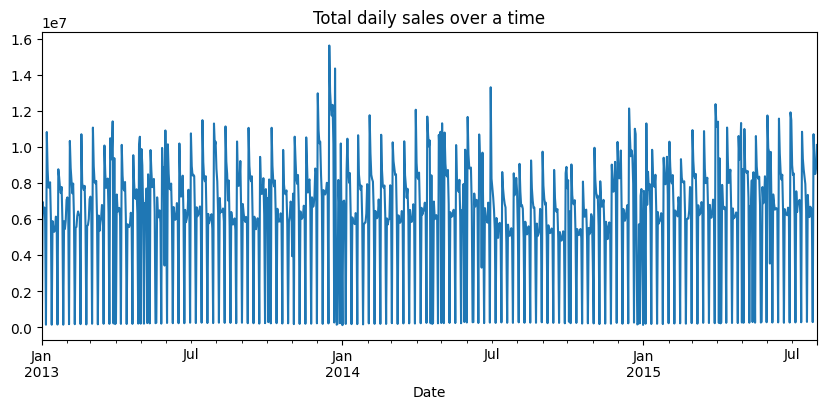

In [14]:
df_open['Date'] = pd.to_datetime(df_open['Date'])

daily_sales = df_open.groupby('Date')['Sales'].sum()
plt.figure(figsize=(10,4))
daily_sales.plot()
plt.title("Total daily sales over a time")
plt.show()


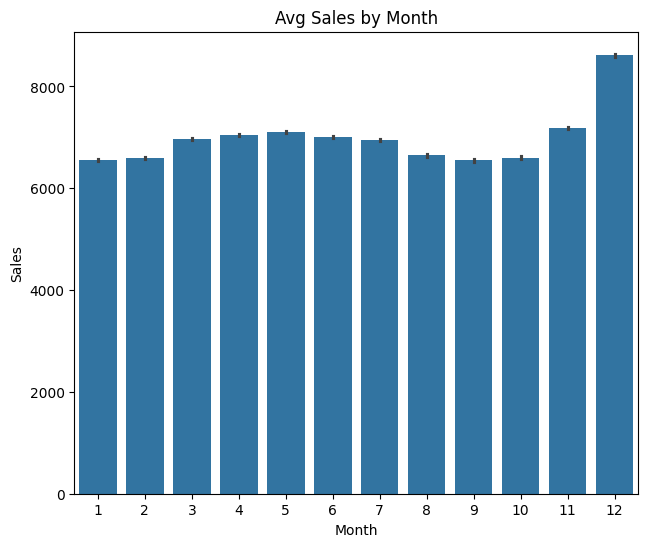

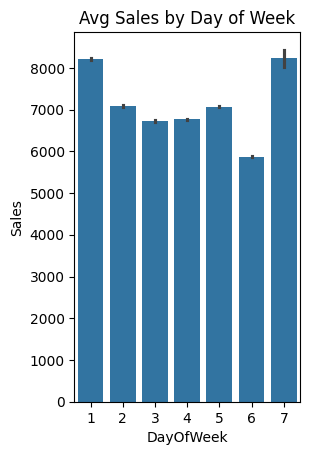

In [20]:
df_open['Month'] = df_open['Date'].dt.month
df_open['DayOfWeekName'] = df_open['Date'].dt.day_name()

plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.barplot(x='Month', y='Sales', data=df_open, estimator=np.mean)
plt.title('Avg Sales by Month')
plt.show()

plt.subplot(1,2,2)
sns.barplot(x='DayOfWeek', y='Sales', data=df_open, estimator=np.mean)
plt.title('Avg Sales by Day of Week')
plt.show()

Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64


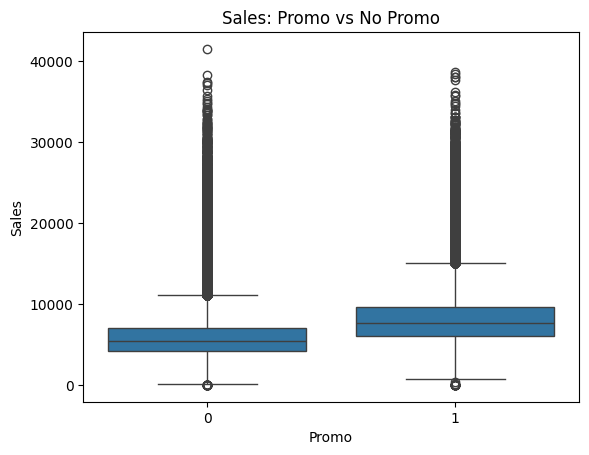

In [21]:
promo_effect = df_open.groupby('Promo')['Sales'].mean()
print(promo_effect)

sns.boxplot(x='Promo', y='Sales', data=df_open)
plt.title('Sales: Promo vs No Promo')
plt.show()

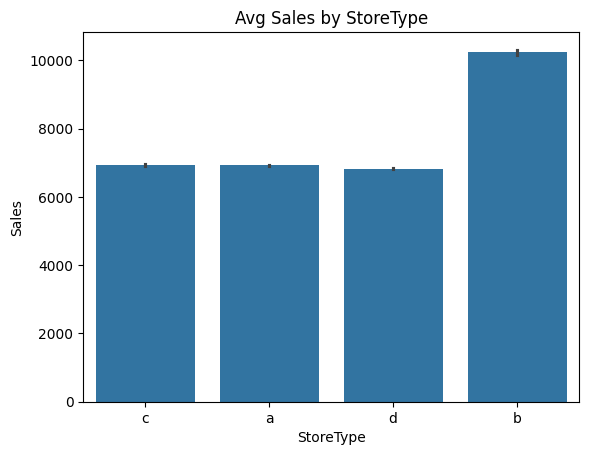

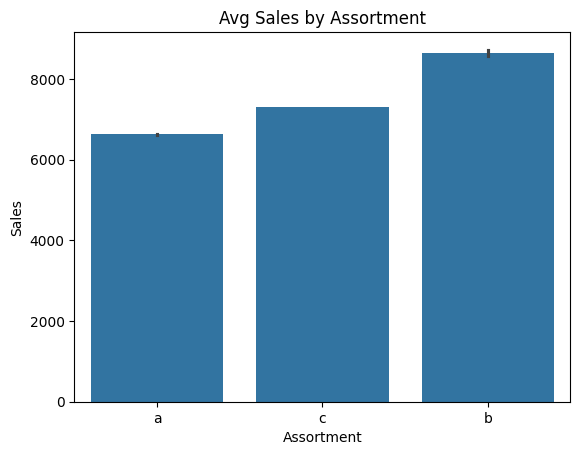

Assortment,a,b,c
StoreType,,,
a,6537.617613,NaN,7573.379923
b,11133.992979,8639.346322,17969.556263
c,6834.931456,NaN,7037.525130
d,6433.619038,NaN,7043.363895


In [22]:
sns.barplot(x='StoreType', y='Sales', data=df_open, estimator=np.mean)
plt.title('Avg Sales by StoreType')
plt.show()

sns.barplot(x='Assortment', y='Sales', data=df_open, estimator=np.mean)
plt.title('Avg Sales by Assortment')
plt.show()

# Combined effect
pd.pivot_table(df_open, values='Sales', index='StoreType', columns='Assortment', aggfunc='mean')

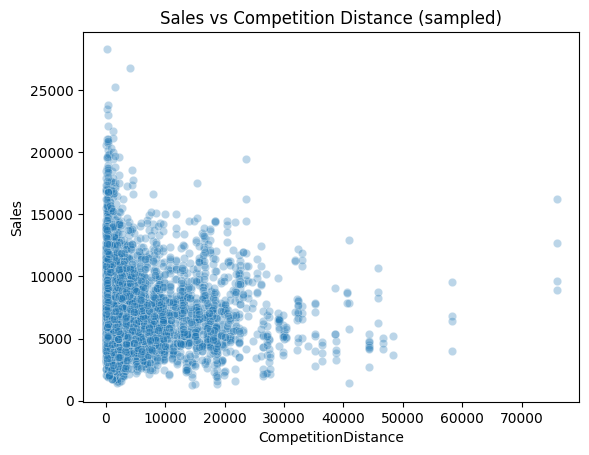

C:\Users\Dhvanish\AppData\Local\Temp\ipykernel_20860\3235001998.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_open.groupby('CompDist_bucket')['Sales'].mean()


CompDist_bucket
(0, 500]           7609.896519
(500, 1000]        6676.218211
(1000, 5000]       6836.022135
(5000, 10000]      6742.587896
(10000, 100000]    6824.760993
Name: Sales, dtype: float64

In [25]:
sns.scatterplot(x='CompetitionDistance', y='Sales', data=df_open.sample(5000), alpha=0.3)
plt.title('Sales vs Competition Distance (sampled)')
plt.show()

# Bucket into ranges for clearer pattern
df_open['CompDist_bucket'] = pd.cut(df_open['CompetitionDistance'], bins=[0,500,1000,5000,10000,100000])
df_open.groupby('CompDist_bucket')['Sales'].mean()

In [ ]:
df.head()

In [ ]:
sns.lineplot(data=df,x='CompetitionDistance',y='Sales')

In [ ]:
df['Date'].min()

In [ ]:
df['Date'].max()

In [ ]:
walker = pyg.walk(df)


In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df['StateHoliday'].value_counts()

In [ ]:
for col in df.columns:
    print(df[col].value_counts())

In [ ]:
df.sample(10)

In [ ]:
df.shape

In [ ]:
df['Open'].value_counts()

In [ ]:
df['StateHoliday'].value_counts()

In [ ]:
df['StoreType'].value_counts()

In [ ]:
df['Assortment'].value_counts()

In [ ]:
print(df['CompetitionDistance'].min())
print(df['CompetitionDistance'].max())
print(df['CompetitionDistance'].nunique())

In [ ]:
df['CompetitionOpenSinceMonth'].value_counts()

In [ ]:
df['CompetitionOpenSinceYear'].value_counts()

In [ ]:
df['Promo'].value_counts()

In [ ]:
df['PromoInterval'].value_counts()

In [ ]:
df.isnull().sum()

In [ ]:
sns.barplot(data=df,x='DayOfWeek',y='Sales')

In [ ]:
sns.barplot(data=df,x='Promo',y='Sales')

In [ ]:
sns.barplot(data=df,x='StateHoliday',y='Sales')

In [ ]:
sns.barplot(data=df,x='SchoolHoliday',y='Sales')

In [ ]:
sns.barplot(data=df,x='StoreType',y='Sales')

In [ ]:
sns.barplot(data=df,x='Assortment',y='Sales')

In [ ]:
sns.barplot(data=df,x='Promo2',y='Sales')

In [ ]:
print("\n--- Visualizing Missing Data Patterns ---")
msno.matrix(df)

In [ ]:
missing_values = ['CompetitionDistance','CompetitionOpenSinceMonth','CompetitionOpenSinceYear','Promo2SinceWeek','Promo2SinceYear','PromoInterval']
for col in missing_values:
    missing_per = df[col].isnull().mean()*100
    print(f'\n {col} : {missing_per}')

In [ ]:
results = associations(df, figsize=(12, 12))
mixed_corr_matrix = results['corr']
print(mixed_corr_matrix)

In [ ]:
weird = ((df['Open'] == 1) & (df['Sales'] == 0)).sum()
weird

In [ ]:
df[df['Promo2'] == 0][['Promo2SinceWeek','Promo2SinceYear','PromoInterval']].isna().mean()

In [ ]:
df['Promo2SinceWeek'].value_counts()

In [ ]:
df['Promo2SinceYear'].value_counts()

In [ ]:
df['PromoInterval'].value_counts()

### Imputing missing values 

In [ ]:
df['CompetitionDistance'].fillna(0,inplace=True)
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df['CompetitionOpen_missing'] = df['CompetitionOpenSinceYear'].isna().astype(int)
df['CompetitionOpenSinceMonth'].fillna(1,inplace=True)
df['CompetitionOpenSinceYear'].fillna(df['Year'].min(),inplace=True)
df['CompetitionOpen'] = 12 * (df['Year'] - df['CompetitionOpenSinceYear']) + (df['Month'] - df['CompetitionOpenSinceMonth'])
df['CompetitionOpen'] = df['CompetitionOpen'].apply(lambda x: max(x, 0))

df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['Promo2OpenSinceMonths'] = 12 * (df['Year'] - df['Promo2SinceYear']) + (df['WeekOfYear'] - df['Promo2SinceWeek']) / 4.0
df['Promo2OpenSinceMonths'] = df['Promo2OpenSinceMonths'].apply(lambda x: max(x, 0) if pd.notnull(x) else 0)
df.loc[df['Promo2'] == 0, 'Promo2OpenSinceMonths'] = 0
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
df['MonthStr'] = df['Month'].map(month_map)
promo_months = df['PromoInterval'].fillna('').str.split(',')
df['IsPromoMonth'] = [
    1 if m in months else 0 
    for m, months in zip(df['MonthStr'], promo_months)
]

df.drop(['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear','Promo2SinceWeek','Promo2SinceYear','PromoInterval','MonthStr'], axis=1, inplace=True)

In [ ]:
df.isnull().sum()

In [ ]:
sns.barplot(data=df,x='Year',y="Sales")

In [ ]:
sns.barplot(data=df,x='Month',y="Sales")

In [ ]:
sns.barplot(data=df,x='CompetitionOpen_missing',y="Sales")

In [ ]:
sns.histplot(data=df,x='CompetitionOpen',y="Sales",bins=50)

In [ ]:
df['CompetitionOpen'].max()

In [ ]:
df[df['CompetitionOpen'] == 1386.0]

In [ ]:
sns.barplot(data=df,x='WeekOfYear',y="Sales")

In [ ]:
sns.histplot(data=df,x='Promo2OpenSinceMonths',y="Sales",bins=50)

In [ ]:
sns.barplot(data=df,x='IsPromoMonth',y='Sales')

In [ ]:
df.info()